# Data Project Nelly Harsch

# Dataset Description

To apply the methods covered in the *Python for Data Analysis* course, I will use a dataset provided by the *EC-funded CAVIAR Project* (IST 2001 37540).

In 2003 and 2004, as part of the CAVIAR project, a number of video clips were recorded depicting different scenarios of interest. These include, among others, people walking alone, meeting with others, window shopping, and entering or exiting shops in a public place.

More information about the project can be be found at:  
http://homepages.inf.ed.ac.uk/rbf/CAVIAR/

For this data analysis project, only the front-view recordings from the second dataset, *Clips from Shopping Center in Portugal*, will be used. This subset contains 26 video sequences, each consisting of approximately 1,500 frames, all recorded from the same camera angle.

# Data Loading

In [25]:
import os
import xml.dom.minidom
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Two sample frames of the dataset can be seen here:
#TwoLeaveShop1front0006.jpg, TwoLeaveSHop2front0350.jpg

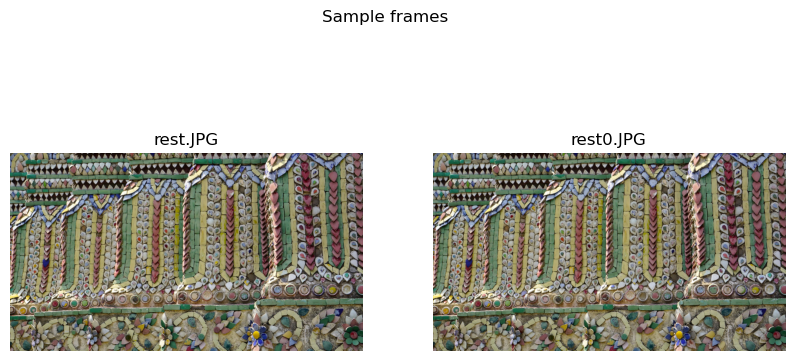

In [23]:
frame_dir = 'sample_frames/'
frame_files = os.listdir(frame_dir)
fig, axes = plt.subplots(1, len(frame_files), figsize = (5*len(frame_files),5))

for ax, frame_name in zip(axes, frame_files):
    frame_path = os.path.join(frame_dir, frame_name)
    img = Image.open(frame_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(frame_path))
    ax.axis("off")
plt.suptitle("Sample frames")
plt.tight_layout
plt.show()

A hugh advantage of this datset is that we not only have access to all frames but also the ground truth. In XML files we can find information on all people present in a frame.
For the first example frame from above the ground truth looks like this:

In [32]:
xml_path = "sample.xml"
with open(xml_path, "r") as f:
    raw_xml = f.read()

dom = xml.dom.minidom.parseString(raw_xml)
pretty_xml = dom.toprettyxml(indent=" ")
lines = pretty_xml.splitlines()
non_empty_lines = [line for line in lines if line.strip()]

print("\n".join(non_empty_lines[:60]))

<?xml version="1.0" ?>
<dataset name="TwoLeaveShop1front">
 <frame number="6">
  <objectlist>
   <object id="0">
    <orientation>90</orientation>
    <box xc="296" yc="134" w="32" h="55"/>
    <appearance>visible</appearance>
    <hypothesislist>
     <hypothesis id="1" prev="1.0" evaluation="1.0">
      <movement evaluation="1.0">walking</movement>
      <role evaluation="1.0">walker</role>
      <context evaluation="1.0">walking</context>
      <situation evaluation="1.0">moving</situation>
     </hypothesis>
    </hypothesislist>
   </object>
  </objectlist>
  <grouplist/>
 </frame>
</dataset>


To work with the ground truth we parse the xml and generate a DataFrame where each row represents one person in one frame.

In [14]:
def parse_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    rows = []
    for frame in root.findall('frame'):
        frame_number = int(frame.get('number'))
        for obj in frame.findall('.objectlist/object'):
            obj_id = int(obj.get('id'))
            box = obj.find('box')
            xc = int(box.get('xc'))
            yc = int(box.get('yc'))
            w = int(box.get('w'))
            h = int(box.get('h'))
            appearance = obj.findtext('appearance')
            orientation = obj.findtext('orientation')

            hyp = obj.find('./hypothesislist/hypothesis')
            if hyp is not None:
                movement = hyp.findtext('movement')
                role = hyp.findtext('role')
                context = hyp.findtext('context')
                situation = hyp.findtext('situation')
            else:
                mobement = role = context = situation = None
            
            rows.append({
                'sequence': os.path.basename(filepath).replace('.xml', ''),
                'frame': frame_number,
                'obj_id': obj_id,
                'xc': xc,
                'yc': yc,
                'h': h,
                'w': w,
                'appearance': appearance,
                'orientation': orientation,
                'movement': movement,
                'role': role,
                'context': context,
                'situation': situation
            })
    return rows

In [ ]:
data_dir = 'data/'
all_rows = []
for filename in sorted(os.listdir(data_dir)):
    if filename.endswith('.xml'):
        filepath = os.path.join(data_dir, filename)
        all_rows.extend(parse_xml(filepath))

df = pd.DataFrame(all_rows)
print(f"Loaded {len(df)} rows from {df['sequence'].nunique()} sequences")
df.head()

Loaded 49614 rows from 26sequences


,sequence,frame,obj_id,xc,yc,h,w,appearance,orientation,movement,role,context,situation
0,EnterExitCrossingPaths1front,0,0,361,139,54,24,appear,90,walking,walker,walking,moving
1,EnterExitCrossingPaths1front,0,1,364,148,53,25,appear,90,walking,walker,walking,moving
2,EnterExitCrossingPaths1front,1,0,362,139,54,21,visible,90,walking,walker,walking,moving
3,EnterExitCrossingPaths1front,1,1,364,148,53,25,visible,90,walking,walker,walking,moving
4,EnterExitCrossingPaths1front,2,0,363,137,51,20,visible,90,walking,walker,walking,moving


Check if there are any unexpected missing values:

In [16]:
df.info()
df['context'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49614 entries, 0 to 49613
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sequence     49614 non-null  object
 1   frame        49614 non-null  int64 
 2   obj_id       49614 non-null  int64 
 3   xc           49614 non-null  int64 
 4   yc           49614 non-null  int64 
 5   h            49614 non-null  int64 
 6   w            49614 non-null  int64 
 7   appearance   49614 non-null  object
 8   orientation  49614 non-null  object
 9   movement     49614 non-null  object
 10  role         49614 non-null  object
 11  context      49614 non-null  object
 12  situation    49614 non-null  object
dtypes: int64(6), object(7)
memory usage: 4.9+ MB


context
walking         12516
shop exit       12332
browsing        11662
shop enter       7268
windowshop       2426
shop reenter     1729
immobile         1681
Name: count, dtype: int64

Check the basic statistics:

In [ ]:
#summary statistics
df.describe()

,frame,obj_id,xc,yc,h,w
count,49614.000000,49614.000000,49614.000000,49614.000000,49614.000000,49614.000000
mean,980.840751,2.953924,221.630608,116.349075,47.972709,18.494397
std,775.863464,3.215412,81.503495,25.208853,18.187212,8.141001
min,0.000000,0.000000,1.000000,66.000000,2.000000,1.000000
25%,411.000000,0.000000,189.000000,98.000000,41.000000,13.000000
50%,784.000000,2.000000,234.000000,123.000000,51.000000,18.000000
75%,1310.000000,4.000000,269.000000,135.000000,57.000000,23.000000
max,3598.000000,14.000000,382.000000,238.000000,150.000000,74.000000


# Features

In this section we will 

In [38]:
def compute_features(track):
    track = track.sort_values('frame')
    dx = track['xc'].diff()
    dy = track['yc'].diff()
    speed = np.sqrt(dx**2 +dy**2)

    area = track['w'] *track['h']
    aspect_ratio = track['h'] / track['w']

    return pd. Series({
        'sequence': track['sequence'].iloc[0],
        'n_frames': len(track),
        'mean_speed': speed.mean(),
        'max_speed': speed.max(),
        'var_x': track['xc'].var(),
        'var_y': track['yc'].var(),
        'mean_w': track['w'].mean(),
        'mean_h': track['h'].mean(),
        'mean_area': area.mean(),
        'std_area': area.std(),
        'mean_aspect': aspect_ratio.mean(),
        'context': track['context'].mode()[0]
    })

tracks_df = df.groupby(['sequence', 'obj_id']).apply(compute_features).reset_index(drop=True)
print(f"{len(tracks_df)} tracks found")
tracks_df.head()

133 tracks found


,sequence,n_frames,mean_speed,max_speed,var_x,var_y,mean_w,mean_h,mean_area,std_area,mean_aspect,context
0,EnterExitCrossingPaths1front,24,1.303291,6.082763,47.853261,3.884058,17.583333,46.333333,870.041667,452.884809,3.457905,walking
1,EnterExitCrossingPaths1front,27,1.218079,5.000000,19.230769,23.230769,17.074074,44.444444,817.333333,414.473252,2.611950,walking
2,EnterExitCrossingPaths1front,281,1.369709,15.132746,4054.490849,613.555465,19.245552,49.156584,1048.142349,649.600329,3.041926,shop exit
3,EnterExitCrossingPaths1front,203,1.163380,21.000000,2123.826513,311.832268,19.083744,48.581281,962.123153,406.278205,2.640899,shop enter
4,EnterExitCrossingPaths2front,470,0.819623,12.649111,4164.602114,558.371565,17.980851,50.678723,977.036170,536.482563,2.963995,shop exit


In [36]:
tracks_df['context'].value_counts()

context
walking         66
shop exit       27
shop enter      16
browsing        14
windowshop       4
shop reenter     3
immobile         3
Name: count, dtype: int64

In [40]:
tracks_df.groupby('context')['mean_speed'].mean().sort_values(ascending=False).round(2)

context
walking         1.80
shop enter      0.99
windowshop      0.86
shop exit       0.84
shop reenter    0.76
browsing        0.57
immobile        0.57
Name: mean_speed, dtype: float64

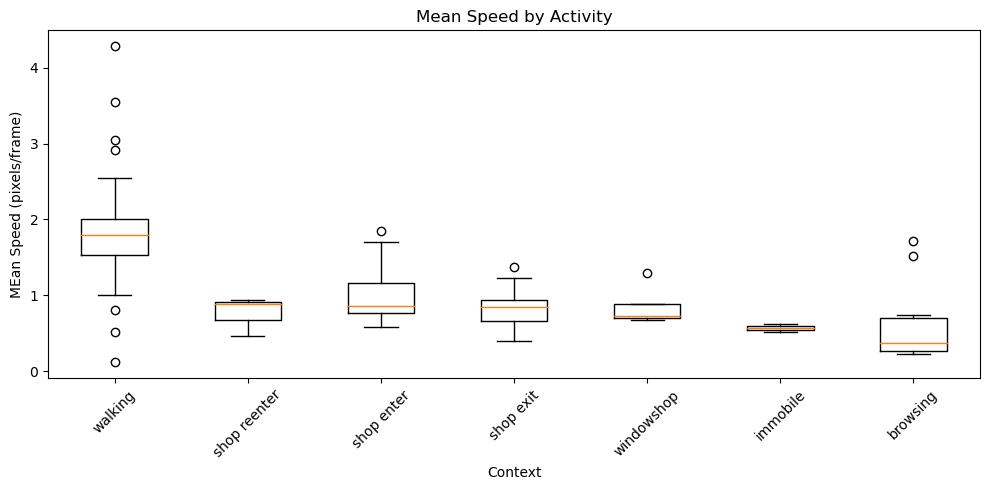

In [39]:
order = tracks_df.groupby('context')['mean_speed'].median().sort_values(ascending= False).index

fig,ax = plt.subplots(figsize = (10,5))
data_plot = [tracks_df[tracks_df['context'] == c]['mean_speed'].values for c in order]
ax.boxplot(data_plot, labels = order)
ax.set_title('Mean Speed by Activity')
ax.set_xlabel('Context')
ax.set_ylabel('MEan Speed (pixels/frame)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Statistical Tests
Next we want to answer the question *Are Walkers faster than Browsers?* 

To do so we implent a two-sample t-test comaring the mean_speed of the walking group against the browsing one. 

**Null Hypothesis:** Walkers and Browsers move at the same speed.

In [47]:
from scipy import stats

In [43]:
walkers = tracks_df[tracks_df['context'] == 'walking']['mean_speed']
browsers = tracks_df[tracks_df['context'] == 'browsing']['mean_speed']
t_stat, p_value = stats.ttest_ind(walkers,browsers)
print(f"Walkers: n = {len(walkers)}, mean={walkers.mean():.2f}")
print(f"Browsers: n={len(browsers)}, mean={browsers.mean():.2f}")
print(f"t-statistic:{t_stat:.3f}")
print(f"p-value:{p_value:.8f}")

Walkers: n = 66, mean=1.80
Browsers: n=14, mean=0.57
t-statistic:6.931
p-value:0.00000000


A t-statistic of 6.9 is very large and confirms that the two groups are well sparated. Furthermore, the p-value is way smaller than 0.05. Therefore, we reject the null hypothesis and conclude, that Walkers are signigicantly faster than browsers.

Next we want to investigate if people entering and exiting the shop behave in the same way. We again run a t-test.

**Null Hypothesis:** People entering and exiting the shop move at the same speed.

In [46]:
entering = tracks_df[tracks_df['context'] == 'shop enter']['mean_speed']
exiting = tracks_df[tracks_df['context'] == 'shop exit']['mean_speed']
t_stat, p_value = stats.ttest_ind(entering,exiting)
print(f"Entering: n = {len(entering)}, mean={entering.mean():.2f}")
print(f"Exiting: n={len(exiting)}, mean={exiting.mean():.2f}")
print(f"t-statistic:{t_stat:.3f}")
print(f"p-value:{p_value:.8f}")

Entering: n = 16, mean=0.99
Exiting: n=27, mean=0.84
t-statistic:1.674
p-value:0.10180951


The result confirms our null hypothesis. With a p-value signigicantly larger than 0.05 we will not reject the null hypothesis and we conclude that a a differentiation between entering and exiting the shop is not possible based on the mean speed. 

# Conclusion
The Data provided by the CAVIAR project offers a wide range of opportunities to use the skills learned in the python course. Using the mean speed to distinguish between different behavois of people is only partly practical. This is also due to the fact that calculating the mean speed the way we did mainly makes sense for people not moving into the depths of images.